## Workflow for Neosurf-on-Neosurf MaSIF search

In [21]:
import os
import pandas as pd

repo_root = !git rev-parse --show-toplevel
repo_root = repo_root[0]
os.chdir(repo_root)

# ----- Directories ------
data_dir = os.path.join(repo_root, 'data')

# ----- Input ------
# .csv about the seed complexes
seed_list_csv = os.path.join(data_dir, 'nico_targets.csv')

# Directory to store input .pdb and .sdf
input_dir = os.path.join(data_dir, 'input')
os.makedirs(input_dir, exist_ok=True)
input_manifest = os.path.join(input_dir, 'input_manifest.csv')

# ----- Output ------
# Directory to write preprocessing files
preprocess_dir = os.path.join(data_dir, 'preprocess')

# Directory to write masif-search output
masif_search_out_dir = os.path.join(data_dir, 'masif_search')
os.makedirs(masif_search_out_dir, exist_ok=True)


___
### Step 1 - preprocess all targets
1. Preprocess targets with ligands in nico_targets.csv
2. Preprocess VHL and CRBN with ligands

In [22]:
df_seed = pd.read_csv(seed_list_csv)

df_seed.head()

,uniprot_id,gene_name,recommendedName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular,formula,mw,qed,num_carbon,num_N_O,uniprot_id_count
0,P35222,CTNNB1,Catenin beta-1,6M90,C,A,J91,2-(2-fluorophenoxy)-3-{[2-oxo-6-(trifluorometh...,c1ccc(c(c1)Oc2c(cccc2NC(=O)C3=CC=C(NC3=O)C(F)(...,1.0,C20H12F4N2O5,436.068234,0.517802,20.0,7.0,1.0
1,P35222,CTNNB1,Catenin beta-1,6M91,C,A,J97,"3-({4-[(2,6-dichlorophenyl)sulfanyl]-2-oxo-6-(...",c1cc(cc(c1)NC(=O)C2=C(C=C(NC2=O)C(F)(F)F)Sc3c(...,1.0,C20H11Cl2F3N2O4S,501.976868,0.408829,20.0,6.0,1.0
2,P35222,CTNNB1,Catenin beta-1,6M92,C,A,J8V,"3-{[2-oxo-4-phenoxy-6-(trifluoromethyl)-1,2-di...",c1ccc(cc1)OC2=C(C(=O)NC(=C2)C(F)(F)F)C(=O)Nc3c...,1.0,C20H13F3N2O5,418.077656,0.577285,20.0,7.0,1.0
3,P35222,CTNNB1,Catenin beta-1,6M93,C,A,J8Y,2-oxo-N-[3-(1H-tetrazol-5-yl)phenyl]-6-(triflu...,c1cc(cc(c1)NC(=O)C2=CC=C(NC2=O)C(F)(F)F)c3[nH]...,1.0,C14H9F3N6O2,350.073908,0.666230,14.0,8.0,1.0
4,P35222,CTNNB1,Catenin beta-1,7AFW,A,A,R9Q,"3-[(2~{R})-4-methyl-5-oxidanylidene-2,3-dihydr...",CN1C[C@H](Oc2ccccc2C1=O)c3cccc(c3)C#N,1.0,C17H14N2O2,278.105528,0.805631,17.0,4.0,1.0


In [3]:
# ----- Helper functions for preparing preprocessing inputs ------
#
# prepare_input_structures() orchestrates one row of df_seed (nico_targets.csv) into
# MaSIF-ready files under input_dir. Per complex the workflow is:
#
#   1. Download the full PDB from RCSB and the ligand SDF (models.rcsb.org) into
#      input_dir / a temp directory.
#   2. Trim the structure to the target protein (standard amino acids on protein_chain)
#      plus a single ligand residue (ligand_code on ligand_chain). If protein_chain
#      and ligand_chain are the same, both are kept on that chain.
#   3. Build a target name {pdb_id}_{chains}, where chains = protein_chain + ligand_chain
#      deduplicated (e.g. C+A -> CA, A+A -> A).
#   4. EvoEF2 RepairStructure on a protein-only PDB (ligand stripped); repaired
#      coordinates are written to a temp file as structure_Repair.pdb.
#   5. Merge the original ligand HETATM/ATOM records from the pre-repair trimmed complex
#      onto the repaired protein and save the final PDB to input_dir.
#   6. Return a dict for df_preprocess: pdb_path, target, ligand ({code}_{chain}),
#      ligand_path ({pdb_id}_{protein_chain}_{ligand_code}.sdf).
#
# Files are always rebuilt (no skip-if-exists). The driver cell loops df_seed and
# calls prepare_input_structures(row, input_dir, repo_root/EvoEF2/EvoEF2).

import shutil
import subprocess
import tempfile
from pathlib import Path
from urllib.error import HTTPError
from urllib.request import urlopen

from Bio.PDB import PDBIO, PDBParser, Select

# chains suffix: protein_chain + ligand_chain, deduplicated (C+A -> CA, A+A -> A)
STANDARD_AA = {
    "ALA", "ARG", "ASN", "ASP", "CYS", "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO", "SER", "THR", "TRP", "TYR", "VAL",
    "MSE",
}

evoef2_bin = os.path.join(repo_root, "EvoEF2", "EvoEF2")

def chain_suffix(protein_chain, ligand_chain):
    if protein_chain == ligand_chain:
        return protein_chain
    return protein_chain + ligand_chain


def _is_standard_protein_residue(residue):
    return residue.id[0] == " " and residue.get_resname().strip() in STANDARD_AA


def _is_ligand_residue(residue, ligand_code):
    return residue.get_resname().strip() == ligand_code.strip()


class _ComplexSelect(Select):
    def __init__(self, protein_chain, ligand_chain, ligand_code):
        self.protein_chain = protein_chain
        self.ligand_chain = ligand_chain
        self.ligand_code = ligand_code
        self._chains = {protein_chain, ligand_chain}

    def accept_chain(self, chain):
        return chain.id in self._chains

    def accept_residue(self, residue):
        chain_id = residue.parent.id
        if chain_id == self.protein_chain:
            if self.protein_chain == self.ligand_chain:
                return _is_standard_protein_residue(residue) or _is_ligand_residue(
                    residue, self.ligand_code
                )
            return _is_standard_protein_residue(residue)
        if chain_id == self.ligand_chain:
            return _is_ligand_residue(residue, self.ligand_code)
        return False


class _ProteinOnlySelect(Select):
    def __init__(self, protein_chain):
        self.protein_chain = protein_chain

    def accept_chain(self, chain):
        return chain.id == self.protein_chain

    def accept_residue(self, residue):
        return _is_standard_protein_residue(residue)


def _download_url(url, dest_path):
    dest_path = Path(dest_path)
    dest_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        with urlopen(url) as response:
            dest_path.write_bytes(response.read())
    except HTTPError as exc:
        raise RuntimeError(f"Download failed ({exc.code}): {url}") from exc


def download_pdb(pdb_id, dest_path):
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    _download_url(url, dest_path)


def download_ligand_sdf(pdb_id, ligand_chain, dest_path):
    url = (
        f"https://models.rcsb.org/v1/{pdb_id}/ligand"
        f"?label_asym_id={ligand_chain}&encoding=sdf"
    )
    _download_url(url, dest_path)


def _extract_ligand_pdb_lines(pdb_path, ligand_chain, ligand_code):
    lines = []
    with open(pdb_path) as handle:
        for line in handle:
            if not (line.startswith("HETATM") or line.startswith("ATOM")):
                continue
            if line[21] != ligand_chain:
                continue
            if line[17:20].strip() != ligand_code.strip():
                continue
            lines.append(line)
    if not lines:
        raise ValueError(
            f"No ligand records for resname={ligand_code} chain={ligand_chain} in {pdb_path}"
        )
    return lines


def _merge_repaired_protein_with_ligand(repaired_pdb, trimmed_pdb, ligand_chain, ligand_code, output_pdb):
    ligand_lines = _extract_ligand_pdb_lines(trimmed_pdb, ligand_chain, ligand_code)
    out_lines = []
    with open(repaired_pdb) as handle:
        for line in handle:
            if line.startswith("END"):
                break
            if line.strip():
                out_lines.append(line)
    out_lines.extend(ligand_lines)
    out_lines.append("END\n")
    Path(output_pdb).write_text("".join(out_lines))


def evoef2_repair_structure(input_pdb, output_pdb, evoef2_bin):
    """Run EvoEF2 RepairStructure; intermediate {stem}_Repair.pdb lives in a temp directory."""
    evoef2_bin = str(evoef2_bin)
    if not os.path.isfile(evoef2_bin):
        raise FileNotFoundError(
            f"EvoEF2 binary not found at {evoef2_bin}. Build with: cd EvoEF2 && ./build.sh"
        )
    output_pdb = Path(output_pdb)
    output_pdb.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        stem = "structure"
        work_pdb = tmp / f"{stem}.pdb"
        shutil.copy2(input_pdb, work_pdb)
        subprocess.run(
            [
                evoef2_bin,
                "--command=RepairStructure",
                f"--pdb={stem}.pdb"
            ],
            cwd=tmp,
            check=True,
        )
        repaired = tmp / f"{stem}_Repair.pdb"
        if not repaired.is_file():
            raise FileNotFoundError(f"EvoEF2 did not create {repaired}")
        shutil.copy2(repaired, output_pdb)


def prepare_input_structures(pdb_id, protein_chain, ligand_chain, ligand_code, input_dir, evoef2_bin):
    """
    Download PDB/SDF, trim to protein+ligand, EvoEF2-repair protein, merge ligand, write to input_dir.

    chains suffix: protein_chain + ligand_chain (deduplicated if equal).
    """
    input_dir = Path(input_dir)

    chains = chain_suffix(protein_chain, ligand_chain)
    target = f"{pdb_id}_{chains}"
    ligand_name = f"{ligand_code}_{ligand_chain}"
    pdb_path = input_dir / f"{target}.pdb"
    ligand_path = input_dir / f"{pdb_id}_{protein_chain}_{ligand_code}.sdf"

    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        full_pdb = tmp / f"{pdb_id}.pdb"
        download_pdb(pdb_id, full_pdb)
        download_ligand_sdf(pdb_id, ligand_chain, ligand_path)

        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb_id, str(full_pdb))

        trimmed_pdb = tmp / "trimmed.pdb"
        pdb_io = PDBIO()
        pdb_io.set_structure(structure)
        pdb_io.save(str(trimmed_pdb), _ComplexSelect(protein_chain, ligand_chain, ligand_code))
        _extract_ligand_pdb_lines(trimmed_pdb, ligand_chain, ligand_code)

        protein_only_pdb = tmp / "protein_only.pdb"
        pdb_io.set_structure(structure)
        pdb_io.save(str(protein_only_pdb), _ProteinOnlySelect(protein_chain))

        repaired_protein_pdb = tmp / "repaired_protein.pdb"
        evoef2_repair_structure(
            protein_only_pdb, repaired_protein_pdb, evoef2_bin
        )
        _merge_repaired_protein_with_ligand(
            repaired_protein_pdb, trimmed_pdb, ligand_chain, ligand_code, pdb_path
        )

    return {
        "pdb_path": str(pdb_path.resolve()),
        "target": target,
        "ligand": ligand_name,
        "ligand_path": str(ligand_path.resolve()),
    }



In [ ]:
# Iterate over all rows in df_seed

rows = []
for _, row in df_seed.iterrows():
    print(f"Preparing {row['pdb_id']} ({row['protein_chain']} + {row['ligand_chain']})...")
    pdb_id = row["pdb_id"]
    protein_chain = row["protein_chain"]
    ligand_chain = row["ligand_chain"]
    ligand_code = row["ligand_code"]
    rows.append(prepare_input_structures(pdb_id, protein_chain, ligand_chain, ligand_code, input_dir, evoef2_bin))

df_preprocess = pd.DataFrame(rows)
df_preprocess.head()

Preparing 6M90 (C + A)...
############################################################################################
                                    EvoEF2                                                  
  A framework for macromolecular modeling, e.g.,protein design, protein side-chain packing, 
protein structure energy minimization, add and optimize hydrogen bonds, build mutant model, 
calculate protein folding stability, calculate protein-protein binding free energy, etc     


  Copyright (c) Xiaoqiang Huang (xiaoqiah@umich.edu; tommyhuangthu@foxmail.com)
  Dept. of Computational Medicine & Bioinformatics
  Medical School
  University of Michigan
############################################################################################
command RepairStructure works
EvoEF Repairing PDB: optimization cycle 1 ... 
We optimize side chain of residue C31L
We optimize side chain of residue C32D
We optimize side chain of residue C35I
We will flip residue C36H to optimize hbond
We 

,pdb_path,target,ligand,ligand_path
0,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M90_CA,J91_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
1,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M91_CA,J97_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
2,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M92_CA,J8V_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
3,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M93_CA,J8Y_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
4,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7AFW_A,R9Q_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
5,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7UWO_AB,WHL_B,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
6,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7ZRB_A,JKI_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
7,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EI9_C,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
8,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EIA_AC,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
9,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EIB_AC,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...


In [ ]:
# Add VHL structure as well:
pdb_id = "8VLB"
protein_chain = "A"
ligand_chain = "A"
ligand_code = "3JF"


rows.append(prepare_input_structures(pdb_id, protein_chain, ligand_chain, ligand_code, input_dir, evoef2_bin))

df_preprocess = pd.DataFrame(rows)

############################################################################################
                                    EvoEF2                                                  
  A framework for macromolecular modeling, e.g.,protein design, protein side-chain packing, 
protein structure energy minimization, add and optimize hydrogen bonds, build mutant model, 
calculate protein folding stability, calculate protein-protein binding free energy, etc     


  Copyright (c) Xiaoqiang Huang (xiaoqiah@umich.edu; tommyhuangthu@foxmail.com)
  Dept. of Computational Medicine & Bioinformatics
  Medical School
  University of Michigan
############################################################################################
command RepairStructure works
EvoEF Repairing PDB: optimization cycle 1 ... 
We optimize side chain of residue A61P
We optimize side chain of residue A62V
We optimize side chain of residue A63L
We optimize side chain of residue A64R
We will rotate hydroxyl group of r

,pdb_path,target,ligand,ligand_path
0,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M90_CA,J91_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
1,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M91_CA,J97_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
2,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M92_CA,J8V_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
3,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M93_CA,J8Y_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
4,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7AFW_A,R9Q_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
5,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7UWO_AB,WHL_B,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
6,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7ZRB_A,JKI_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
7,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EI9_C,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
8,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EIA_AC,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
9,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EIB_AC,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...


In [ ]:
# Add CRBN-pomalidomide structure as well:
pdb_id = "6H0F"
protein_chain = "B"
ligand_chain = "B"
ligand_code = "Y70"

rows.append(prepare_input_structures(pdb_id, protein_chain, ligand_chain, ligand_code, input_dir, evoef2_bin))

df_preprocess = pd.DataFrame(rows)

############################################################################################
                                    EvoEF2                                                  
  A framework for macromolecular modeling, e.g.,protein design, protein side-chain packing, 
protein structure energy minimization, add and optimize hydrogen bonds, build mutant model, 
calculate protein folding stability, calculate protein-protein binding free energy, etc     


  Copyright (c) Xiaoqiang Huang (xiaoqiah@umich.edu; tommyhuangthu@foxmail.com)
  Dept. of Computational Medicine & Bioinformatics
  Medical School
  University of Michigan
############################################################################################
command RepairStructure works
EvoEF Repairing PDB: optimization cycle 1 ... 
We optimize side chain of residue B70R
We will rotate hydroxyl group of residue B71T to optimize hbond
We optimize side chain of residue B71T
We optimize side chain of residue B72L
We will f

,pdb_path,target,ligand,ligand_path
0,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M90_CA,J91_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
1,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M91_CA,J97_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
2,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M92_CA,J8V_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
3,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,6M93_CA,J8Y_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
4,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7AFW_A,R9Q_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
5,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7UWO_AB,WHL_B,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
6,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,7ZRB_A,JKI_A,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
7,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EI9_C,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
8,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EIA_AC,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...
9,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...,8EIB_AC,WHL_C,/scratch/ymeng/NNeosurf/masif-neosurf/data/inp...


In [24]:
# Write df_preprocess to input_manifest.csv, then run preprocess_array.sh
df_preprocess.to_csv(input_manifest, index=False)
n_rows = len(df_preprocess)
manifest_abs = os.path.abspath(input_manifest)
# Use {var} for Python values in ! commands — ${var} becomes a literal '$' + path in Jupyter
!sbatch --array=1-{n_rows} scripts/slurm/preprocess_array.sh {manifest_abs}

sbatch: [ESTIMATION] The estimated cost of this job is CHF 0.05
sbatch: ╭──────────────────────────────┬─────────────┬─────────────┬─────────────╮
sbatch: │ [in CHF]                     │ Capping     │ Consumed    │ Queued ¹⁾ ²⁾│
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ username : ymeng             │ 0           │ 1.25        │ 0.1         │
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ account : upthomae           │ 10,000      │ 1.45        │ 0.1         │
sbatch: ╰──────────────────────────────┴─────────────┴─────────────┴─────────────╯
sbatch: ¹⁾ Estimated cost of the queued jobs and this job
sbatch: ²⁾ Queued jobs costs are based on its walltime (option --time)
Submitted batch job 54908372


___
### Step 2 - Run masif_search around ligand residues
1. Query with VHL structure as target, search for seed patches around the seed ligands

In [30]:
from pathlib import Path

df_preprocess = pd.read_csv(input_manifest)

QUERY_TARGET = "8VLB_A"
query_out_dir = os.path.join(masif_search_out_dir, QUERY_TARGET)
subset_dir = Path(query_out_dir) / "subset"

# Clear the subset directory before writing new seeds
if subset_dir.exists():
    shutil.rmtree(subset_dir)
subset_dir.mkdir(parents=True, exist_ok=True)

# Seeds to search (all preprocessed targets except the query)
seed_ids = df_preprocess.loc[df_preprocess["target"] != QUERY_TARGET, "target"].tolist()

# Evenly split all seed ids across N_SUBSET files (one masif_search.py call per file)
N_SUBSET = 10
chunks = [[] for _ in range(N_SUBSET)]
for i, seed_id in enumerate(seed_ids):
    chunks[i % N_SUBSET].append(seed_id)

for chunk_ix, chunk in enumerate(chunks, start=1):
    if chunk:
        (subset_dir / str(chunk_ix)).write_text("\n".join(chunk) + "\n")

n_subsets = sum(1 for chunk in chunks if chunk)

subset_dir_abs = os.path.abspath(subset_dir)
print(f"Query target: {QUERY_TARGET}")
print(f"Wrote {len(seed_ids)} seed(s) into {n_subsets} subset file(s) under {subset_dir}")
print(
    f"Submit: sbatch --array=1-{n_subsets} scripts/slurm/search_array.sh "
    f"{QUERY_TARGET} {query_out_dir} {subset_dir_abs}"
)


Query target: 8VLB_A
Wrote 27 seed(s) into 10 subset file(s) under /scratch/ymeng/NNeosurf/masif-neosurf/data/masif_search/8VLB_A/subset
Submit: sbatch --array=1-10 scripts/slurm/search_array.sh 8VLB_A /scratch/ymeng/NNeosurf/masif-neosurf/data/masif_search/8VLB_A /scratch/ymeng/NNeosurf/masif-neosurf/data/masif_search/8VLB_A/subset


In [31]:
query_out_dir_abs = os.path.abspath(query_out_dir)
!sbatch --array=1-{n_subsets} scripts/slurm/search_array.sh {QUERY_TARGET} {query_out_dir_abs} {subset_dir_abs}

sbatch: [ESTIMATION] The estimated cost of this job is CHF 0.08
sbatch: ╭──────────────────────────────┬─────────────┬─────────────┬─────────────╮
sbatch: │ [in CHF]                     │ Capping     │ Consumed    │ Queued ¹⁾ ²⁾│
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ username : ymeng             │ 0           │ 1.3         │ 0.1         │
sbatch: ├──────────────────────────────┼─────────────┼─────────────┼─────────────┤
sbatch: │ account : upthomae           │ 10,000      │ 1.5         │ 0.1         │
sbatch: ╰──────────────────────────────┴─────────────┴─────────────┴─────────────╯
sbatch: ¹⁾ Estimated cost of the queued jobs and this job
sbatch: ²⁾ Queued jobs costs are based on its walltime (option --time)
Submitted batch job 54920022


In [32]:
import sys
from pathlib import Path

import pandas as pd

masif_seed_search_source = Path("../masif_seed_search/source").resolve()
if str(masif_seed_search_source) not in sys.path:
    sys.path.insert(0, str(masif_seed_search_source))

def gather_search_results(results_root, query_target):
    """Concatenate per-protein hit CSVs under results_root/query_target/site_*."""
    target_dir = Path(results_root) / query_target
    if not target_dir.is_dir():
        raise FileNotFoundError(f"No search output directory: {target_dir}")

    frames = []
    for site_dir in sorted(target_dir.glob("site_*")):
        for csv_path in sorted(site_dir.glob("*.csv")):
            frames.append(pd.read_csv(csv_path))

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)



results_csv = os.path.join(query_out_dir, f"{QUERY_TARGET}_search_results.csv")
df_results = gather_search_results(query_out_dir, QUERY_TARGET)
df_results.to_csv(results_csv, index=False)
print(f"Wrote {len(df_results)} matches to {results_csv}")
df_results.head()


Wrote 41 matches to /scratch/ymeng/NNeosurf/masif-neosurf/data/masif_search/8VLB_A/8VLB_A_search_results.csv


,target,target_site,target_vix,matched_protein,matched_patch_id,score,desc_dist_score,clashing_ca,clashing_heavy,matched_vix,desc_dist,iface_score,mean_desc_dist_score,flattened_transform
0,8VLB_A,site_0,1603,6H0F_B,92,0.913902,26.330341,0,1,5831,2.620379,0.893827,0.189427,"0.6858977626369402,-0.7271322416101107,-0.0286..."
1,8VLB_A,site_12,655,7UWO_AB,47,0.960794,11.189148,0,2,6226,3.865346,0.250972,0.121621,"0.9879234313976613,-0.13975212155902544,0.0669..."
2,8VLB_A,site_12,10,8EIB_AC,44,0.927137,18.196810,0,3,2800,2.614950,0.623639,0.133800,"0.15812950636497491,0.5389018949130736,-0.8273..."
3,8VLB_A,site_14,2318,7UWO_AB,72,0.912026,10.356243,0,2,6226,2.983407,0.250972,0.107878,"0.8520539445775033,0.407236253644337,-0.328880..."
4,8VLB_A,site_17,1153,6H0F_B,92,0.923392,14.635022,0,1,6108,3.504168,0.413766,0.150877,"0.9891916236962184,-0.016364789493193976,0.145..."


In [33]:
from pathlib import Path

import numpy as np
from Bio.PDB import PDBParser
from sklearn.cluster import DBSCAN
from tqdm import tqdm

RMSD_THRESH = 5.0


def get_transformed_struct(row, database_root=preprocess_dir):
    """Apply MaSIF alignment transform to the preprocessed seed structure."""
    pdb_path = Path(database_root, "data_preparation", "01-benchmark_pdbs", f"{row.matched_protein}.pdb")
    struct = PDBParser(QUIET=True).get_structure(row.matched_protein, pdb_path)
    transform = np.array(list(map(float, row.flattened_transform.split(",")))).reshape(4, 4)
    struct.transform(rot=transform[:3, :3].T, tran=transform[:3, 3])
    return struct


def structural_clusters(df, rmsd_thresh=RMSD_THRESH, database_root=preprocess_dir):
    """
    Cluster alignments per matched_protein by backbone RMSD (DBSCAN).
    Adds cluster_id, cluster_size, cluster_mean_rmsd (ported from tricomplex src/utils.py).
    """

    def get_coords(struct, atoms_to_keep=("N", "CA", "C")):
        return np.stack([a.get_coord() for a in struct.get_atoms() if a.name in atoms_to_keep])

    def rmsd(coords1, coords2):
        assert coords1.shape == coords2.shape
        diff = coords1 - coords2
        return np.sqrt(np.mean(np.sum(diff * diff, axis=-1)))

    current_cluster_label = 0
    for domain_name in tqdm(df.matched_protein.unique(), desc="structural_clusters"):
        domain_table = df[df.matched_protein == domain_name]

        if len(domain_table) == 1:
            df.loc[domain_table.index, "cluster_id"] = current_cluster_label
            df.loc[domain_table.index, "cluster_size"] = 1
            df.loc[domain_table.index, "cluster_mean_rmsd"] = 0.0
            current_cluster_label += 1
            continue

        positions = [
            get_coords(get_transformed_struct(row, database_root=database_root))
            for _, row in domain_table.iterrows()
        ]

        rmsd_vals = np.zeros((len(domain_table), len(domain_table)))
        for i in range(len(domain_table)):
            for j in range(i + 1, len(domain_table)):
                rmsd_ij = rmsd(positions[i], positions[j])
                rmsd_vals[i, j] = rmsd_ij
                rmsd_vals[j, i] = rmsd_ij

        labels = DBSCAN(eps=rmsd_thresh, min_samples=2, metric="precomputed").fit_predict(rmsd_vals)
        labels[labels == -1] = np.arange((labels == -1).sum()) + labels.max() + 1

        for lb in set(labels):
            cluster_table = domain_table.iloc[labels == lb]
            df.loc[cluster_table.index, "cluster_id"] = current_cluster_label
            df.loc[cluster_table.index, "cluster_size"] = len(cluster_table)
            df.loc[cluster_table.index, "cluster_mean_rmsd"] = rmsd_vals[labels == lb][:, labels == lb].mean(axis=1)
            current_cluster_label += 1

    return df


def deduplicate_by_cluster(df, group_cols=("target", "matched_protein", "cluster_id"), score_col="score"):
    """Keep the highest-scoring row per group (tricomplex deduplicate_csv / cys-mutant workflow)."""
    idx = df.groupby(list(group_cols))[score_col].idxmax()
    return df.loc[idx].reset_index(drop=True)


df_clustered = structural_clusters(df_results.copy(), database_root=preprocess_dir)
df_deduplicated = deduplicate_by_cluster(df_clustered)

dedup_csv = os.path.join(query_out_dir, f"{QUERY_TARGET}_search_results_deduplicated.csv")
df_deduplicated.to_csv(dedup_csv, index=False)
print(f"Clustered {len(df_clustered)} matches -> {len(df_deduplicated)} after deduplication")
print(f"Wrote {dedup_csv}")
df_deduplicated.head()


structural_clusters: 100%|██████████| 7/7 [00:02<00:00,  2.57it/s]

Clustered 41 matches -> 14 after deduplication
Wrote /scratch/ymeng/NNeosurf/masif-neosurf/data/masif_search/8VLB_A/8VLB_A_search_results_deduplicated.csv


,target,target_site,target_vix,matched_protein,matched_patch_id,score,desc_dist_score,clashing_ca,clashing_heavy,matched_vix,desc_dist,iface_score,mean_desc_dist_score,flattened_transform,cluster_id,cluster_size,cluster_mean_rmsd
0,8VLB_A,site_4,3024,5QSO_A,83,0.984994,18.718812,0,3,7999,2.258849,0.251634,0.133706,"0.19107555978801924,-0.6229866621367615,0.7585...",9.0,17.0,1.519843
1,8VLB_A,site_0,1603,6H0F_B,92,0.913902,26.330341,0,1,5831,2.620379,0.893827,0.189427,"0.6858977626369402,-0.7271322416101107,-0.0286...",0.0,1.0,0.000000
2,8VLB_A,site_17,1153,6H0F_B,92,0.923392,14.635022,0,1,6108,3.504168,0.413766,0.150877,"0.9891916236962184,-0.016364789493193976,0.145...",1.0,1.0,0.000000
3,8VLB_A,site_45,2232,6H0F_B,34,0.907080,21.893635,0,4,2023,1.802906,0.883637,0.195479,"0.6007553819359233,-0.48149134015626804,0.6381...",2.0,1.0,0.000000
4,8VLB_A,site_45,2232,6H0F_B,65,0.936170,23.565419,0,0,3639,2.320815,0.890190,0.216197,"0.596593664546763,-0.48518992623468793,0.63927...",3.0,1.0,0.000000


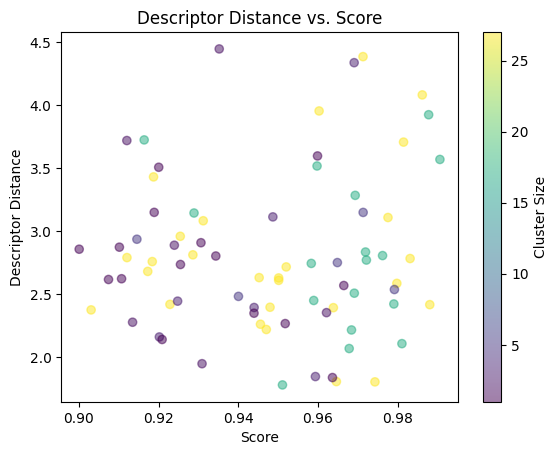

In [20]:
# Plot desc_dist ~ score, color by cluster_size
import matplotlib.pyplot as plt

# Make sure df_results has 'cluster_size'
sc = plt.scatter(
    df_clustered["score"], 
    df_clustered["desc_dist"], 
    c=df_clustered["cluster_size"] if "cluster_size" in df_clustered.columns else None, 
    cmap="viridis",
    alpha=0.5
)
plt.xlabel("Score")
plt.ylabel("Descriptor Distance")
plt.title("Descriptor Distance vs. Score")
if "cluster_size" in df_clustered.columns:
    cbar = plt.colorbar(sc)
    cbar.set_label("Cluster Size")

In [9]:

def print_pymol_commands(row):
    matched_protein = row["matched_protein"]
    matched_pdb = matched_protein.split("_")[0]
    matched_chains = matched_protein.split("_")[1]
    matched_patch_id = row["matched_patch_id"]
    flattened_transform = row["flattened_transform"]

    # Split matched_chains (e.g. "AB") into ["A", "B"]
    matched_chains = list(matched_chains)
    # Joint matched_chains into a string (e.g. "chain A chain B")
    matched_chains_str = "chain " + " chain ".join(matched_chains)

    print(f"fetch {matched_pdb}, {matched_protein}_{matched_patch_id}")
    #print(f"select {matched_protein}_{matched_patch_id} AND (not {matched_chains_str})")
    #print('cmd.remove("sele");cmd.delete("sele")')
    print(f"apply_transform {matched_protein}_{matched_patch_id}, '{flattened_transform}'")

# Apply to all rows
df_deduplicated.apply(print_pymol_commands, axis=1)

fetch 5QSO, 5QSO_A_83
apply_transform 5QSO_A_83, '0.20439356822717916,-0.603617169868853,0.7706293411925575,119.50955596136306,0.24031590482899043,-0.7322151452857537,-0.6372670138179015,50.28208585786603,0.9489317863543119,0.31544776628417887,-0.004601259907589771,92.58105709855789,0.0,0.0,0.0,1.0'
fetch 5QSO, 5QSO_A_1
apply_transform 5QSO_A_1, '-0.3557638509341224,0.23985998308908935,0.9032714270256897,62.796813754675725,0.09008787435818963,-0.9532018023071366,0.2886009337684977,83.50309710558105,0.9302237673066343,0.18404758240989777,0.3175062678860452,105.3450549119238,0.0,0.0,0.0,1.0'
fetch 5QSO, 5QSO_A_63
apply_transform 5QSO_A_63, '-0.019081956528580246,0.1497468915446468,0.9885402103140553,93.62046905428898,-0.11183932456366316,-0.9828347292136824,0.1467237558564101,63.81812092957658,0.9935430762761042,-0.10775789309458395,0.03550200078349536,107.72885987723612,0.0,0.0,0.0,1.0'
fetch 5QSO, 5QSO_A_64
apply_transform 5QSO_A_64, '0.949408735505089,-0.14743408231565933,-0.277283689

0     None
1     None
2     None
3     None
4     None
5     None
6     None
7     None
8     None
9     None
10    None
11    None
12    None
13    None
14    None
15    None
16    None
17    None
18    None
19    None
20    None
21    None
22    None
23    None
24    None
25    None
26    None
27    None
28    None
29    None
dtype: object